In [34]:
#importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/iris


#Loading Data and preprocessing

In [3]:
data = pd.read_csv(path + "/Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
data.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [5]:
data = data.sample(frac=1, random_state=42)
data = data.reset_index(drop=True)
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,74,6.1,2.8,4.7,1.2,Iris-versicolor
1,19,5.7,3.8,1.7,0.3,Iris-setosa
2,119,7.7,2.6,6.9,2.3,Iris-virginica
3,79,6.0,2.9,4.5,1.5,Iris-versicolor
4,77,6.8,2.8,4.8,1.4,Iris-versicolor
...,...,...,...,...,...,...
145,72,6.1,2.8,4.0,1.3,Iris-versicolor
146,107,4.9,2.5,4.5,1.7,Iris-virginica
147,15,5.8,4.0,1.2,0.2,Iris-setosa
148,93,5.8,2.6,4.0,1.2,Iris-versicolor


In [6]:
X = data.drop(["Species", "Id"], axis=1)
y = data.Species

print(X)
print(y)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              6.1           2.8            4.7           1.2
1              5.7           3.8            1.7           0.3
2              7.7           2.6            6.9           2.3
3              6.0           2.9            4.5           1.5
4              6.8           2.8            4.8           1.4
..             ...           ...            ...           ...
145            6.1           2.8            4.0           1.3
146            4.9           2.5            4.5           1.7
147            5.8           4.0            1.2           0.2
148            5.8           2.6            4.0           1.2
149            7.1           3.0            5.9           2.1

[150 rows x 4 columns]
0      Iris-versicolor
1          Iris-setosa
2       Iris-virginica
3      Iris-versicolor
4      Iris-versicolor
            ...       
145    Iris-versicolor
146     Iris-virginica
147        Iris-setosa
148    Iris-versicolor
14

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
print(X_scaled)

[[ 3.10997534e-01 -5.87763531e-01  5.35295827e-01  1.75297293e-03]
 [-1.73673948e-01  1.72626612e+00 -1.17067529e+00 -1.18150376e+00]
 [ 2.24968346e+00 -1.05056946e+00  1.78634131e+00  1.44795564e+00]
 [ 1.89829664e-01 -3.56360566e-01  4.21564419e-01  3.96171883e-01]
 [ 1.15917263e+00 -5.87763531e-01  5.92161531e-01  2.64698913e-01]
 [-5.37177559e-01  8.00654259e-01 -1.28440670e+00 -1.05003079e+00]
 [-2.94841818e-01 -3.56360566e-01 -9.02269170e-02  1.33225943e-01]
 [ 1.28034050e+00  1.06445364e-01  7.62758643e-01  1.44795564e+00]
 [ 4.32165405e-01 -1.97618132e+00  4.21564419e-01  3.96171883e-01]
 [-5.25060772e-02 -8.19166497e-01  8.03701950e-02  1.75297293e-03]
 [ 7.95669016e-01  3.37848329e-01  7.62758643e-01  1.05353673e+00]
 [-1.26418478e+00 -1.24957601e-01 -1.34127240e+00 -1.44444970e+00]
 [-4.16009689e-01  1.03205722e+00 -1.39813811e+00 -1.31297673e+00]
 [-1.14301691e+00  1.06445364e-01 -1.28440670e+00 -1.44444970e+00]
 [-9.00681170e-01  1.72626612e+00 -1.28440670e+00 -1.18150376e

#Using KNN classifier

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

In [15]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [16]:
y_pred = knn.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9736842105263158


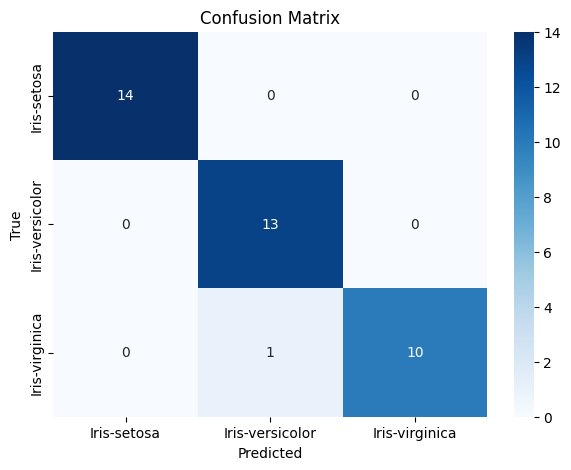

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#Experimenting with different K values

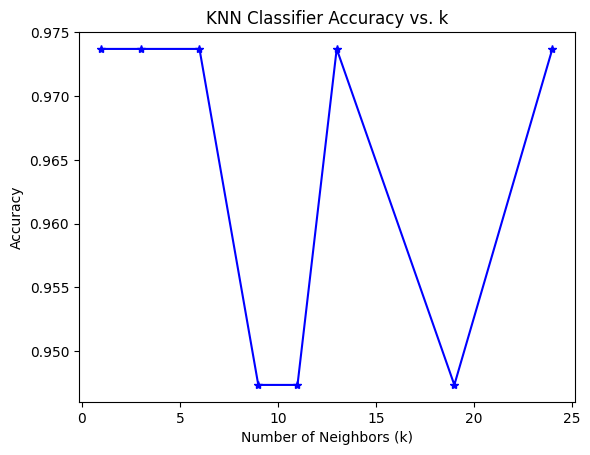

In [30]:
k_values = [1, 3, 6, 9, 11, 13, 19, 24]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='*', color='b')
plt.title('KNN Classifier Accuracy vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.show()


#Plotting Decsion Boundary

In [35]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train_encoded)

h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [41]:
a = np.unique(y_train_encoded)
b = y_train.unique()
print(f"{a} = {b}")

[0 1 2] = ['Iris-versicolor' 'Iris-virginica' 'Iris-setosa']


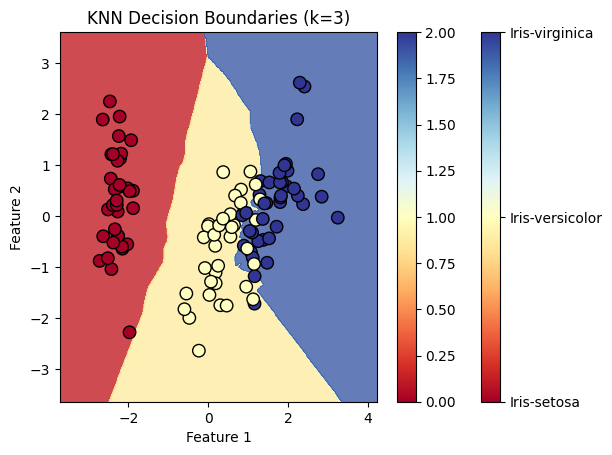

In [42]:
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_encoded, edgecolors='k', marker='o', s=80, cmap=plt.cm.RdYlBu)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k=3)')
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2])  # because label_encoder mapped 0,1,2
cbar.set_ticklabels(encoder.classes_)
plt.colorbar()
plt.show()